## “Exploratory Data Analysis of Netflix Movies and TV Shows using Python”

# Problem Statement

The rapid growth of online streaming platforms has significantly changed the way audiences consume entertainment content. Among these platforms, Netflix offers a vast collection of movies and TV shows across different genres, countries, and languages. Analyzing such large-scale content data can help in understanding trends, audience preferences, and content distribution patterns.

The main objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset using Python. The project focuses on data cleaning, handling missing values, analyzing content trends, and visualizing insights related to content type, release years, ratings, genres, duration, and country-wise contributions. Through this analysis, the project aims to identify meaningful patterns and provide a better understanding of Netflix’s content library and its growth over time

## Objectives of the Project
* To analyze Movies and TV Shows distribution
* To identify top contributing countries
* To analyze release year trends
* To study ratings and genres
* To handle missing and duplicate data
* To visualize insights using graphs and charts
* To understand Netflix content growth over time

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline

In [44]:
df = pd.read_csv("netflix_titles.csv")

In [45]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [46]:
df.shape

(8807, 12)

In [47]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [48]:
df.info() #dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [49]:
df.describe(include="all") #statical summary

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# Data Cleaning


In [50]:
#Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [51]:
#Handle missing values
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Not Available')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['date_added'] = df['date_added'].fillna('Unknown')
# Fixed: 0 min causes errors for TV shows; fill correctly per type
df['duration'] = df.apply(
    lambda x: '0 min' if pd.isna(x['duration']) and x['type'] == 'Movie'
    else ('0 Season' if pd.isna(x['duration']) else x['duration']), axis=1
)



In [52]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [54]:
#Convert date_added column into datetime
# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [55]:
# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [81]:
df[['duration_num', 'duration_type']] = df['duration'].str.split(' ', expand=True)
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

# Exploratory Data Analysis (EDA)

#   1: Movies vs TV Shows

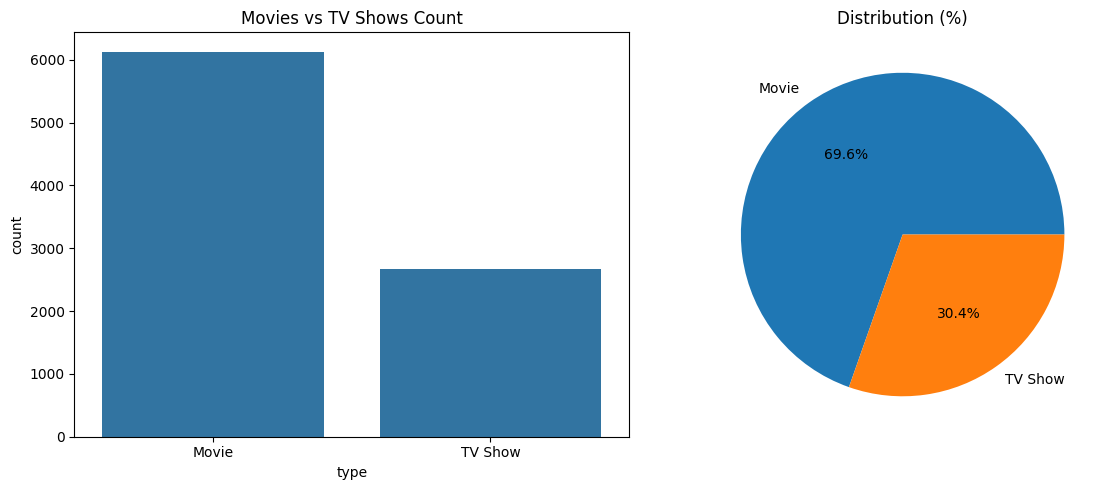

In [83]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='type', data=df, ax=axes[0])
axes[0].set_title('Movies vs TV Shows Count')

axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
axes[1].set_title('Distribution (%)')

plt.tight_layout()
plt.show()

# 
Insight:
Netflix has approximately 70% Movies and 30% TV Shows. Movies dominate the platform, but TV Shows still make up a significant portion of the content library.



# 2: Content Released Over the Years

In [60]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

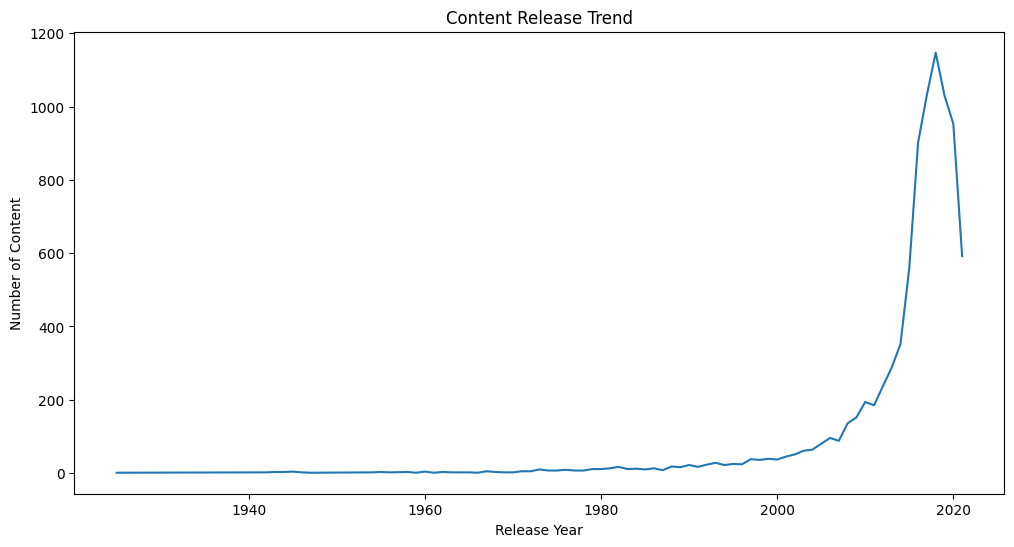

In [61]:
plt.figure(figsize=(12,6))

df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Content")
plt.show()

#
Insight:Netflix content growth increased rapidly after 2015.

# 3: Top 10 Countries Producing Content

In [62]:
country_series = df['country'].str.split(', ').explode().str.strip()
country_series = country_series[country_series != 'Unknown']
top_countries = country_series.value_counts().head(10)
print(top_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


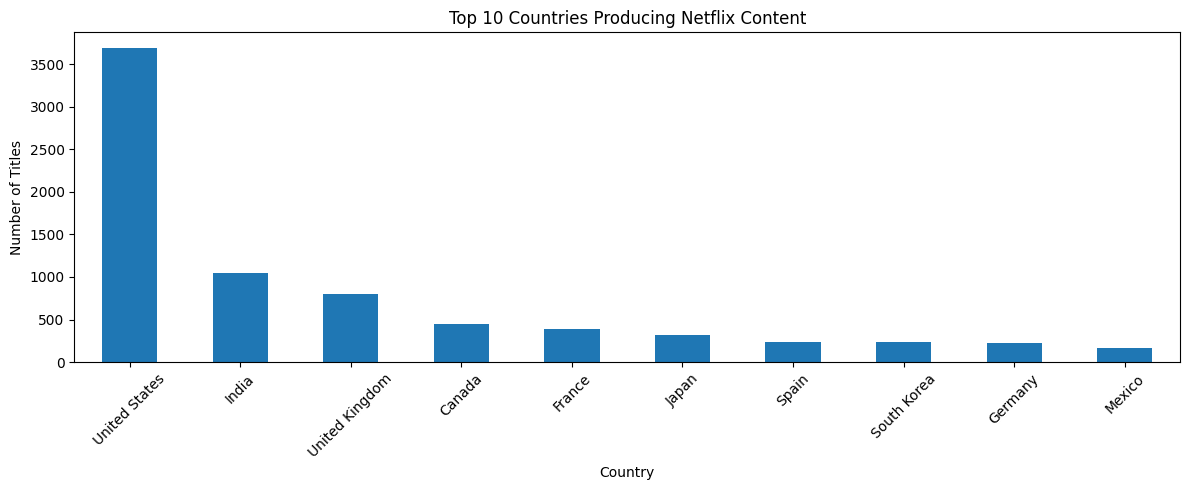

In [63]:
plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 
Insight: United States contributes the highest amount of content on Netflix, followed by India and the United Kingdom.

# 4: Most Common Ratings

In [64]:
df['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

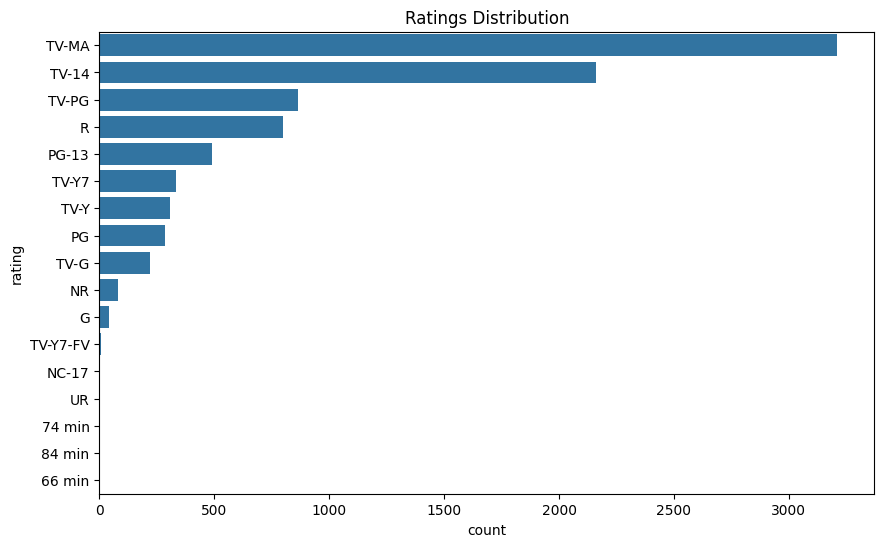

In [65]:
plt.figure(figsize=(10,6))
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Ratings Distribution")
plt.show()

# 
Insight:TV-MA rating is the most frequently occurring rating on Netflix.

# 5: Top Genres on Netflix

In [66]:
genre_series = df['listed_in'].str.split(', ').explode().str.strip()
top_genres = genre_series.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


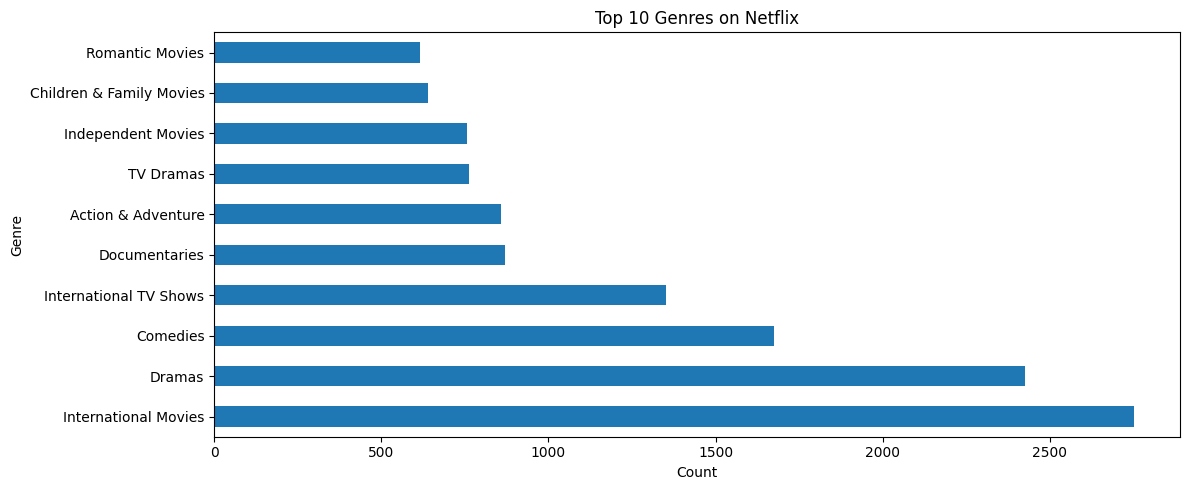

In [67]:
plt.figure(figsize=(12, 5))
top_genres.plot(kind='barh')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# 
Insight:Drama and International Movies are among the most popular genres.

# 6: Content Added Each Year

In [68]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

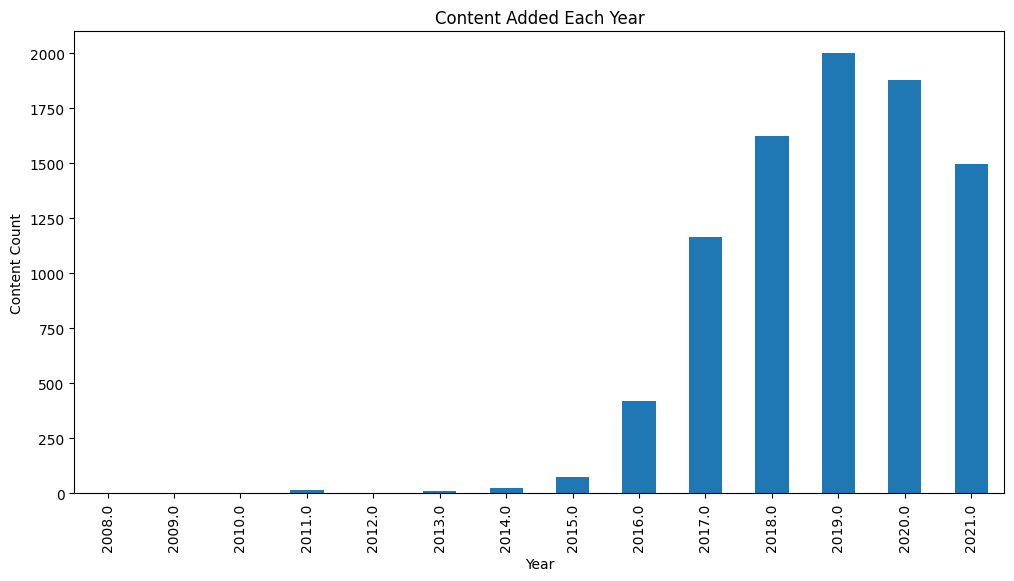

In [69]:
plt.figure(figsize=(12,6))

df['year_added'].value_counts().sort_index().plot(kind='bar')

plt.title("Content Added Each Year")
plt.xlabel("Year")
plt.ylabel("Content Count")
plt.show()

#
Insight:Netflix significantly expanded its content library after 2016.

# 7:Month-wise Content Addition 

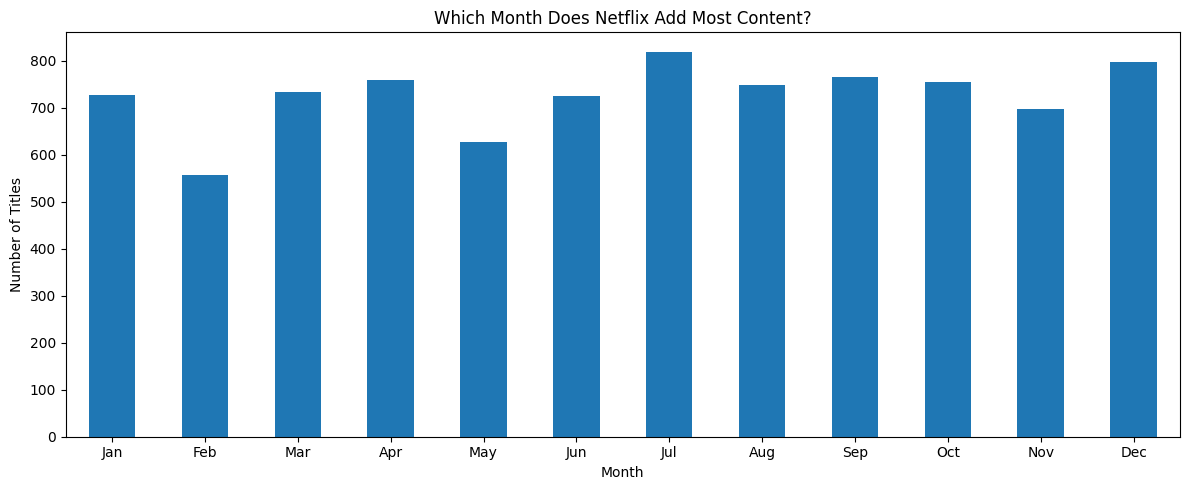

In [70]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = df['month_added'].value_counts().sort_index()
monthly.index = [month_names[m] for m in monthly.index]

plt.figure(figsize=(12, 5))
monthly.plot(kind='bar')
plt.title('Which Month Does Netflix Add Most Content?')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 
Insight:Netflix adds the most content in January and July, likely aligned with holiday viewing seasons and mid-year release schedules.

# 8: Longest Movies

In [71]:
movies = df[df['type'] == 'Movie']

movies.sort_values(by='duration_num',
                   ascending=False)[['title','duration']].head(10)

,title,duration
4253,Black Mirror: Bandersnatch,312 min
717,Headspace: Unwind Your Mind,273 min
2491,The School of Mischief,253 min
2487,No Longer kids,237 min
2484,Lock Your Girls In,233 min
2488,Raya and Sakina,230 min
166,Once Upon a Time in America,229 min
7932,Sangam,228 min
1019,Lagaan,224 min
4573,Jodhaa Akbar,214 min


#
Insight:Some movies on Netflix exceed 3 hours in duration.

# 9:Top 10 Directors

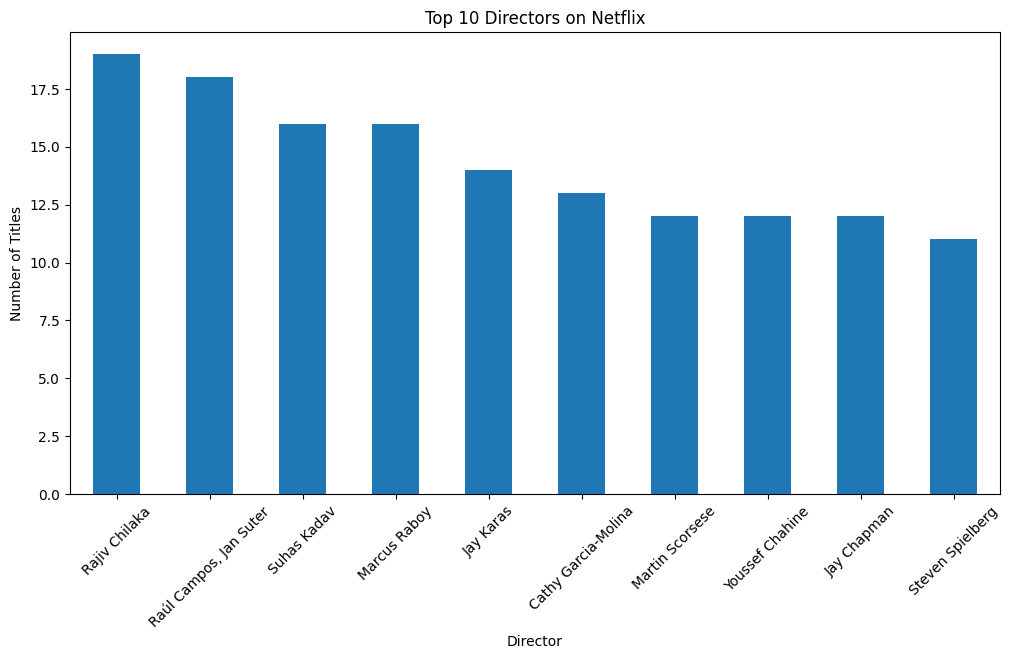

In [72]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_directors.plot(kind='bar')

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()


# 
insight:
After excluding missing values, the analysis shows that certain directors have contributed multiple titles to Netflix. This indicates repeated collaborations between Netflix and popular directors, helping the platform maintain audience engagement through recognized creators.

# 10:Country × Rating Heatmap


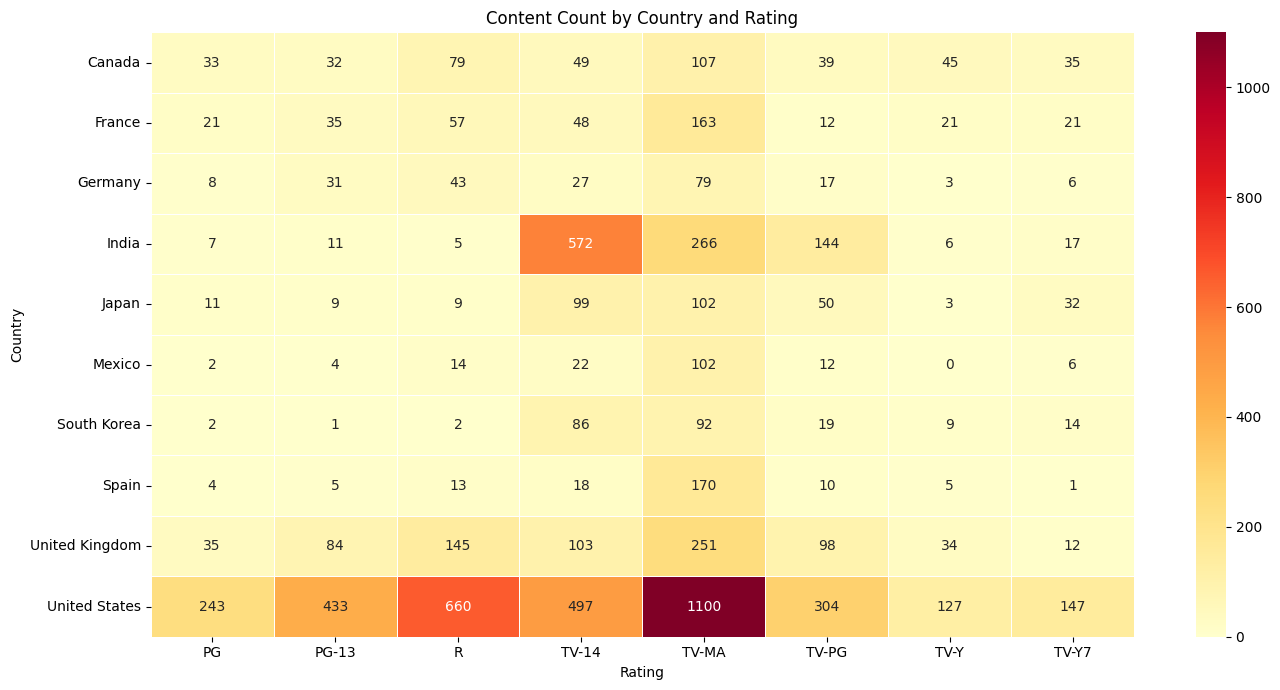

In [80]:
# Country vs Rating Heatmap
df_exploded = df.copy()
df_exploded['country'] = df_exploded['country'].str.split(', ')  # split first
df_exploded = df_exploded.explode('country')                      # then explode the whole dataframe
df_exploded['country'] = df_exploded['country'].str.strip()       # then strip spaces

top_10 = df_exploded[df_exploded['country'] != 'Unknown']['country'].value_counts().head(10).index
top_8_ratings = df['rating'].value_counts().head(8).index

df_filtered = df_exploded[df_exploded['country'].isin(top_10) & df_exploded['rating'].isin(top_8_ratings)]

pivot = df_filtered.pivot_table(index='country', columns='rating', aggfunc='size', fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Content Count by Country and Rating')
plt.xlabel('Rating')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#
Insight:The United States dominates TV-MA and TV-14 ratings. India's content is concentrated in TV-MA, while Japan and South Korea have notable TV-14 content.

# 11:Top 10 Cast Members

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


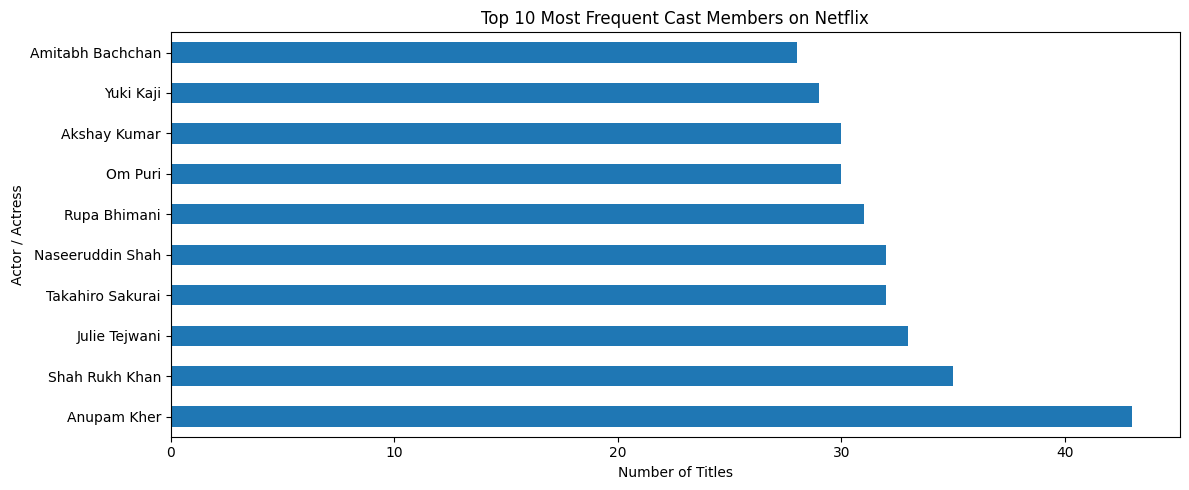

In [74]:
cast_series = df[df['cast'] != 'Not Available']['cast'].str.split(', ').explode().str.strip()
top_cast = cast_series.value_counts().head(10)
print(top_cast)

plt.figure(figsize=(12, 5))
top_cast.plot(kind='barh')
plt.title('Top 10 Most Frequent Cast Members on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Actor / Actress')
plt.tight_layout()
plt.show()

# 
Insight: Certain actors appear across a large number of Netflix titles, indicating recurring collaborations with the platform — especially in Indian and international cinema.


# 12: Word Cloud on Descriptions

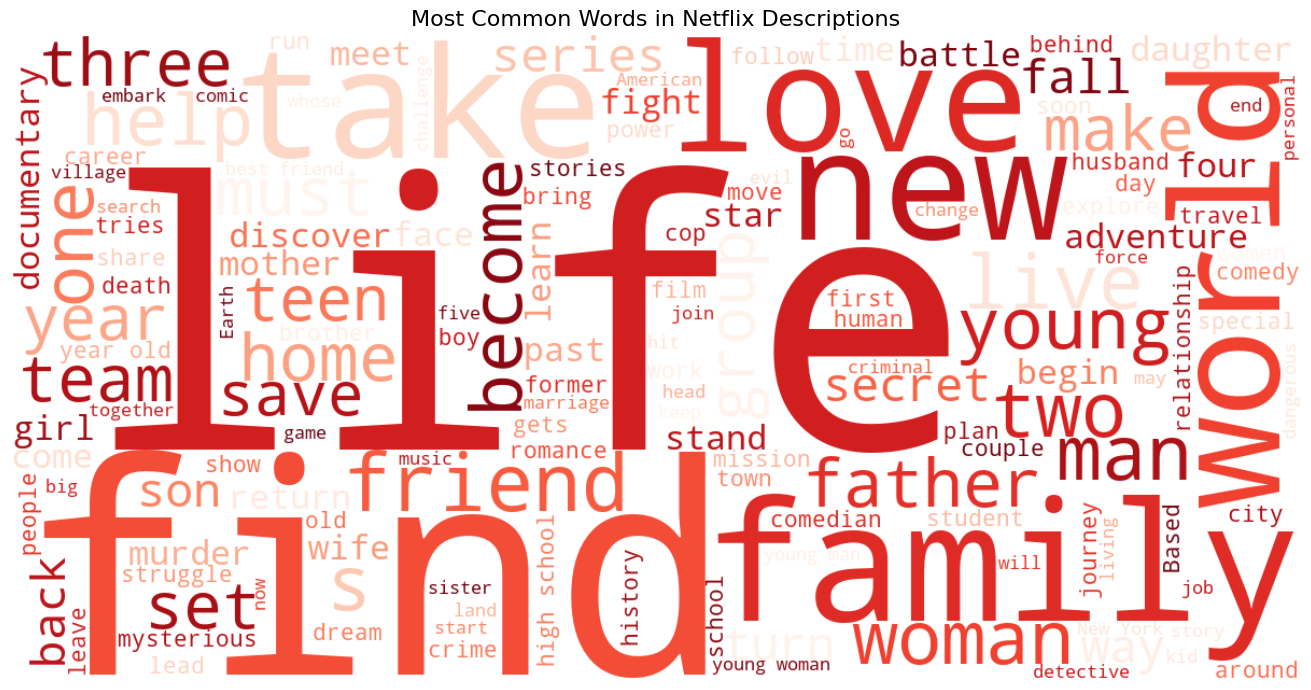

In [75]:
text = ' '.join(df['description'].dropna().astype(str).tolist())

wordcloud = WordCloud(width=1200, height=600,
                      background_color='white',
                      colormap='Reds',
                      max_words=150).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Descriptions', fontsize=16)
plt.tight_layout()
plt.show()

# 
Insight: Words like "life", "family", "love", "young", and "find" dominate Netflix descriptions, reflecting common storytelling themes around relationships and personal journeys.

# key findings:
* Netflix contains approximately 70% Movies and 30% TV Shows.

* United States is the top content-producing country, followed by India and the United Kingdom.

* Content additions grew rapidly after 2015, peaking around 2019–2020.

* TV-MA is the most common rating, dominating both Movies and TV Shows.

* Dramas and International Movies are the most popular individual genres on Netflix.

* Netflix adds the most content in January and July, aligned with holiday and mid-year seasons.

* The United States dominates TV-MA and TV-14 ratings, while India's content is concentrated in TV-MA.

* Certain directors and cast members appear across multiple titles, showing strong repeat partnerships with Netflix.

* Common themes in Netflix descriptions include family, life, love, and relationships.

# Conclusion:

This project successfully performed Exploratory Data Analysis on the Netflix Movies and TV Shows dataset using Python. The analysis helped in understanding Netflix’s content distribution, growth trends, ratings, genres, and country-wise contributions.

Using data cleaning, preprocessing, and visualization techniques, meaningful insights were generated from the dataset. The project demonstrates how Python libraries such as Pandas, Matplotlib, Seaborn, and WordCloud can be effectively used for real-world data analysis tasks.

# Future Enhancements:
* Build recommendation systems
* Perform sentiment analysis on reviews
* Create interactive dashboards using Plotly
* Apply machine learning models for prediction